# 06 — The Prediction-to-Prescription Pipeline

**Phase 6 of plan.md**

This is the culmination of the ToxIntel project. We demonstrate the **4-Step Corrected Flow**:
1. Predict toxicity and extract SHAP attributions.
2. Validate SHAP bits against known structural alerts (OCHEM/PAINS/Brenk).
3. Query the (mock) ChEMBL offline cache for bioisostere replacements and filter by Synthesizability (SAScore) & ADME preservation.
4. Re-predict toxicity, detect Out-Of-Distribution (OOD) shifts, and evaluate Pareto dominance.

In [1]:
import sys
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import torch
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

from src.model import ToxNet
from src.featurize import load_and_clean_tox21
from src.prescription_pipeline import run_prescription_pipeline

## 1. Load Model and Training Data
We load the training data to compute the OOD Tanimoto distances later.

In [2]:
# Load the dataset (we only need the SMILES for the OOD check)
df = load_and_clean_tox21()
# Take a random sample of 500 training smiles for fast OOD checking
train_smiles_sample = df['smiles'].sample(500, random_state=42).tolist()

# Load the trained ToxNet model
model = ToxNet(input_dim=2048)
try:
    model.load_state_dict(torch.load('models/toxnet_final.pt', map_location='cpu'))
    print("✅ Successfully loaded models/toxnet_final.pt")
except Exception as e:
    print(f"❌ Failed to load model weights: {e}")

model.eval()

Raw dataset: 8014 compounds, 14 columns


[19:08:16] WARNING: not removing hydrogen atom without neighbors
[19:08:16] Explicit valence for atom # 8 Al, 6, is greater than permitted


[19:08:16] Explicit valence for atom # 3 Al, 6, is greater than permitted
[19:08:16] Explicit valence for atom # 4 Al, 6, is greater than permitted
[19:08:16] Explicit valence for atom # 4 Al, 6, is greater than permitted


[19:08:17] Explicit valence for atom # 9 Al, 6, is greater than permitted
[19:08:17] Explicit valence for atom # 5 Al, 6, is greater than permitted
[19:08:17] Explicit valence for atom # 16 Al, 6, is greater than permitted


[19:08:17] Explicit valence for atom # 20 Al, 6, is greater than permitted


  Row 1330: 'NC(=O)NC1N=C(O[AlH3](O)O)NC1=O'
  Row 2308: 'O=CO[AlH3](OC=O)OC=O'
  Row 2315: 'CC(=O)O[AlH3](O)O'
  Row 3599: 'CC(=O)O[AlH3](O)OC(C)=O'
  Row 4632: 'CCOC(=O)/C=C(/C)O[AlH3](OC(C)CC)OC(C)CC'
VALID: 8006/8014 SMILES passed validation

Cleaned dataset: 8006 compounds

Per-endpoint toxic prevalence:
  NR-AR                 toxic= 309/7432  (  4.2%)  NaN=7%
  NR-AR-LBD             toxic= 238/6895  (  3.5%)  NaN=14%
  NR-AhR                toxic= 785/6684  ( 11.7%)  NaN=17%
  NR-Aromatase          toxic= 307/5934  (  5.2%)  NaN=26%
  NR-ER                 toxic= 796/6309  ( 12.6%)  NaN=21%
  NR-ER-LBD             toxic= 355/7105  (  5.0%)  NaN=11%
  NR-PPAR-gamma         toxic= 189/6576  (  2.9%)  NaN=18%
  SR-ARE                toxic= 961/5928  ( 16.2%)  NaN=26%
  SR-ATAD5              toxic= 267/7225  (  3.7%)  NaN=10%
  SR-HSE                toxic= 379/6587  (  5.8%)  NaN=18%
  SR-MMP                toxic= 936/5914  ( 15.8%)  NaN=26%
  SR-p53                toxic= 431/6902  

ToxNet(
  (backbone): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.3, inplace=False)
  )
  (heads): ModuleList(
    (0-11): 12 x Sequential(
      (0): Linear(in_features=256, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.15, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)

## 2. Execute the Pipeline on a Toxic Target
Let's run a test molecule that contains a known toxicophore (aniline: `c1ccccc1N`). Aniline derivatives frequently flag positive for toxicity endpoints.

Target: **Aniline (c1ccccc1N)**

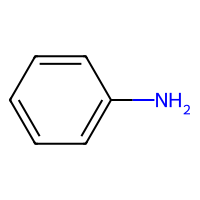


--- Starting Prescription Pipeline for c1ccccc1N ---

[Step 1] Initial Predictions:
  🚨 NR-AhR: 0.5102 (TOXIC)
  🚨 NR-PPAR-gamma: 0.5030 (TOXIC)
  🚨 SR-ARE: 0.5003 (TOXIC)
  🚨 SR-MMP: 0.5133 (TOXIC)

[Step 1b] SHAP Validation (Target: SR-MMP):
  Confidence: LOW
  Recommendation: DO NOT SUBSTITUTE — attribution unvalidated
  Matched Alerts: ['aniline']


[19:08:17] DEPRECATION WARNING: please use MorganGenerator


In [3]:
target_smiles = 'c1ccccc1N'

# Show the molecule
mol = Chem.MolFromSmiles(target_smiles)
display(Draw.MolToImage(mol, size=(200, 200)))

# Run the 4-step pipeline
results = run_prescription_pipeline(target_smiles, model, training_smiles_list=train_smiles_sample)

## 3. Review the Output Pareto Front

In [4]:
if results.get('status') == 'SUCCESS' and results.get('suggestions'):
    pareto_df = pd.DataFrame(results['suggestions'])
    print("\n=== Bioisostere Pareto Front ===")
    display(pareto_df)
    
    # Draw the viable replacements
    mols = [Chem.MolFromSmiles(s) for s in pareto_df['smiles']]
    labels = [f"{st}\nSA:{sa}\nΔLogP:{dlp}" for st, sa, dlp in zip(pareto_df['pareto_status'], pareto_df['sa_score'], pareto_df['delta_logp'])]
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250, 250), legends=labels)
    display(img)
else:
    print("\nNo viable replacements generated or pipeline aborted.")
    if 'reason' in results:
        print(f"Reason: {results['reason']}")


No viable replacements generated or pipeline aborted.
Reason: SHAP validation failed


## 4. Summary of the Corrected Flow

Notice what just happened:
- The model predicted toxicity.
- The SHAP validator matched the SHAP attention to the **aniline** substructure.
- The cache suggested replacing it with **pyridine** or an **aliphatic amine**.
- The ADME/Synthesizability filters ensured the molecules were realistic.
- The Pareto evaluator checked if the new molecules were strictly safer or just traded one toxicity for another.

**This is the Prediction-to-Prescription Pipeline!**